# Unsupervised LSTM Learning for Hand Sign Detection

This notebook implements **unsupervised learning** for hand sign/gesture recognition using LSTM Autoencoders and clustering.

## Approach
Instead of using labeled data for supervised classification, we:
1. Extract hand landmark features from videos using MediaPipe
2. Train an LSTM Autoencoder to learn compact representations
3. Cluster the learned representations
4. Map clusters to signs from `wlasl_class_list.txt`

## Why Unsupervised?
- Works with unlabeled or partially labeled data
- Discovers natural groupings in gesture data
- Useful for exploring new gesture datasets
- Can identify similar gestures that might be confused

In [52]:
# Install dependencies if needed
# !pip install mediapipe opencv-python tensorflow scikit-learn umap-learn

In [53]:
%pip install tqdm mediapipe umap-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
import cv2
from collections import defaultdict
from tqdm.notebook import tqdm

# MediaPipe for hand detection
try:
    import mediapipe as mp
    mp_hands = mp.solutions.hands
    mp_drawing = mp.solutions.drawing_utils
    MEDIAPIPE_AVAILABLE = True
except ImportError:
    print("MediaPipe not available - will use precomputed features if available")
    MEDIAPIPE_AVAILABLE = False

# ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False

# TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, RepeatVector, 
    TimeDistributed, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"MediaPipe: {MEDIAPIPE_AVAILABLE}")
print(f"UMAP: {UMAP_AVAILABLE}")

  Using cached mediapipe-0.10.33-py3-none-win_amd64.whl.metadata (9.8 kB)
  Using cached umap_learn-0.5.11-py3-none-any.whl.metadata (26 kB)
  Using cached sounddevice-0.5.5-py3-none-win_amd64.whl.metadata (1.4 kB)
  Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
  Using cached numba-0.65.0-cp312-cp312-win_amd64.whl.metadata (3.0 kB)
  Using cached pynndescent-0.6.0-py3-none-any.whl.metadata (6.9 kB)
Using cached mediapipe-0.10.33-py3-none-win_amd64.whl (10.6 MB)
Using cached sounddevice-0.5.5-py3-none-win_amd64.whl (365 kB)
Using cached umap_learn-0.5.11-py3-none-any.whl (90 kB)
Using cached numba-0.65.0-cp312-cp312-win_amd64.whl (2.7 MB)
Using cached pynndescent-0.6.0-py3-none-any.whl (73 kB)
Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl (183 kB)
Using cached opencv_contrib_python-4.13.0.92-cp37-abi3-win_amd64.whl (46.5 MB)

   ---------------------------------------- 0/7 

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\Users\\suman\\Documents\\hand_sign_detection_dynamic\\venv\\Lib\\site-packages\\cv2\\cv2.pyd'
Check the permissions.



In [54]:
# Configuration
DATA_DIR = Path("../data")
VIDEOS_DIR = DATA_DIR / "videos"
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

CONFIG = {
    # Feature extraction
    "max_frames": 30,           # Frames per video sequence
    "n_landmarks": 21,          # Hand landmarks per hand
    "n_coords": 3,              # x, y, z per landmark
    "n_hands": 2,               # Max hands to detect
    
    # Autoencoder
    "encoding_dim": 32,         # Latent space dimension
    "lstm_units": 64,           # LSTM layer units
    "dropout_rate": 0.2,
    
    # Training
    "batch_size": 32,
    "epochs": 100,
    "learning_rate": 0.001,
    "patience": 10,
    
    # Clustering
    "n_clusters": None,         # Will be set from class list
}

# Calculate features per frame
CONFIG["n_features"] = CONFIG["n_landmarks"] * CONFIG["n_coords"] * CONFIG["n_hands"]  # 126
print(f"Features per frame: {CONFIG['n_features']}")

Features per frame: 126


---
## 1. Load Target Signs

Load the list of signs we want to recognize from `wlasl_class_list.txt`.

In [55]:
def load_class_list(filepath):
    """Load sign classes from wlasl_class_list.txt"""
    classes = {}
    with open(filepath, 'r') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                idx, name = int(parts[0]), parts[1]
                classes[idx] = name
    return classes

# Load class list
class_list_path = DATA_DIR / "wlasl_class_list.txt"
if class_list_path.exists():
    sign_classes = load_class_list(class_list_path)
    CONFIG["n_clusters"] = len(sign_classes)
    print(f"Loaded {len(sign_classes)} sign classes")
    print(f"First 10: {list(sign_classes.values())[:10]}")
else:
    sign_classes = {i: f"sign_{i}" for i in range(10)}
    CONFIG["n_clusters"] = 10
    print("Class list not found, using default 10 clusters")

Loaded 2000 sign classes
First 10: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']


---
## 2. Data Loading & Feature Extraction

Extract hand landmarks from video files using MediaPipe, or load precomputed features.

In [56]:
class VideoFeatureExtractor:
    """Extract hand landmark features from videos using MediaPipe."""
    
    def __init__(self, max_frames=30, n_landmarks=21, n_hands=2):
        self.max_frames = max_frames
        self.n_landmarks = n_landmarks
        self.n_hands = n_hands
        self.n_features = n_landmarks * 3 * n_hands  # x,y,z per landmark per hand
        
        if MEDIAPIPE_AVAILABLE:
            self.hands = mp_hands.Hands(
                static_image_mode=False,
                max_num_hands=n_hands,
                min_detection_confidence=0.5,
                min_tracking_confidence=0.5
            )
    
    def extract_from_video(self, video_path):
        """Extract features from a single video file."""
        if not MEDIAPIPE_AVAILABLE:
            return None
        
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        
        while cap.isOpened() and len(frames) < self.max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            
            # Convert BGR to RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(rgb_frame)
            
            # Extract landmarks
            frame_features = np.zeros(self.n_features)
            
            if results.multi_hand_landmarks:
                for hand_idx, hand_landmarks in enumerate(results.multi_hand_landmarks[:self.n_hands]):
                    start_idx = hand_idx * self.n_landmarks * 3
                    for lm_idx, lm in enumerate(hand_landmarks.landmark):
                        base = start_idx + lm_idx * 3
                        frame_features[base] = lm.x
                        frame_features[base + 1] = lm.y
                        frame_features[base + 2] = lm.z
            
            frames.append(frame_features)
        
        cap.release()
        
        if len(frames) == 0:
            return None
        
        # Pad or truncate to max_frames
        frames = np.array(frames)
        if len(frames) < self.max_frames:
            padding = np.zeros((self.max_frames - len(frames), self.n_features))
            frames = np.vstack([frames, padding])
        else:
            frames = frames[:self.max_frames]
        
        return frames
    
    def extract_from_directory(self, video_dir, extensions=['.mp4', '.avi', '.mov']):
        """Extract features from all videos in a directory."""
        video_dir = Path(video_dir)
        video_files = []
        for ext in extensions:
            video_files.extend(video_dir.glob(f"**/*{ext}"))
        
        print(f"Found {len(video_files)} video files")
        
        features = []
        video_names = []
        labels = []  # Will try to extract from filename/folder
        
        for video_path in tqdm(video_files, desc="Extracting features"):
            feat = self.extract_from_video(video_path)
            if feat is not None:
                features.append(feat)
                video_names.append(video_path.stem)
                
                # Try to get label from parent folder or filename
                label = video_path.parent.name if video_path.parent != video_dir else "unknown"
                labels.append(label)
        
        return np.array(features), video_names, labels

extractor = VideoFeatureExtractor(
    max_frames=CONFIG["max_frames"],
    n_landmarks=CONFIG["n_landmarks"],
    n_hands=CONFIG["n_hands"]
)

In [57]:
def load_or_extract_features():
    """Load precomputed features or extract from videos."""
    
    # Try precomputed features first
    x_path = DATA_DIR / "X_data.npy"
    y_path = DATA_DIR / "y_data.npy"
    
    if x_path.exists() and y_path.exists():
        print("Loading precomputed features...")
        X = np.load(x_path)
        y = np.load(y_path, allow_pickle=True)
        
        # Reshape if needed
        if len(X.shape) == 2:
            n_samples = X.shape[0]
            timesteps = CONFIG["max_frames"]
            n_features = X.shape[1] // timesteps
            X = X.reshape(n_samples, timesteps, n_features)
        
        print(f"Loaded: X={X.shape}, y={y.shape}")
        return X, y, list(range(len(y)))
    
    # Try extracting from videos
    if VIDEOS_DIR.exists() and MEDIAPIPE_AVAILABLE:
        print("Extracting features from videos...")
        X, names, labels = extractor.extract_from_directory(VIDEOS_DIR)
        
        if len(X) > 0:
            print(f"Extracted: X={X.shape}")
            return X, np.array(labels), names
    
    # Generate demo data
    print("No data available - generating synthetic demo data...")
    return generate_demo_data()


def generate_demo_data(n_samples=500, n_classes=10):
    """Generate synthetic demo data for testing."""
    timesteps = CONFIG["max_frames"]
    n_features = CONFIG["n_features"]
    samples_per_class = n_samples // n_classes
    
    X_list, y_list = [], []
    class_names = list(sign_classes.values())[:n_classes] if len(sign_classes) >= n_classes else \
                  [f"gesture_{i}" for i in range(n_classes)]
    
    for class_idx in range(n_classes):
        for _ in range(samples_per_class):
            t = np.linspace(0, 4 * np.pi, timesteps)
            freq = 1 + class_idx * 0.3
            phase = class_idx * 0.5
            
            features = np.zeros((timesteps, n_features))
            for f in range(n_features):
                features[:, f] = np.sin(freq * t + phase + f * 0.05) + np.random.normal(0, 0.15, timesteps)
            
            X_list.append(features)
            y_list.append(class_names[class_idx])
    
    X = np.array(X_list)
    y = np.array(y_list)
    idx = np.random.permutation(len(y))
    
    print(f"Generated: X={X.shape}, classes={n_classes}")
    return X[idx], y[idx], [f"sample_{i}" for i in idx]

# Load data
X_raw, y_labels, video_names = load_or_extract_features()
print(f"\nData shape: {X_raw.shape}")
print(f"Unique labels: {len(np.unique(y_labels))}")

Loading precomputed features...
Loaded: X=(11, 30, 8), y=(11,)

Data shape: (11, 30, 8)
Unique labels: 6


In [58]:
# Preprocess: normalize features
n_samples, timesteps, n_features = X_raw.shape

# Handle missing values
X_clean = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# Normalize
X_flat = X_clean.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(n_samples, timesteps, n_features)

print(f"Preprocessed shape: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

Preprocessed shape: (11, 30, 8)
Mean: 0.0000, Std: 1.0000


---
## 3. LSTM Autoencoder for Unsupervised Learning

The autoencoder learns to compress sequences into a latent representation and reconstruct them.
The encoder output (latent space) captures the essential patterns in the gesture sequences.

```
Input Sequence → [Encoder LSTM] → Latent Vector → [Decoder LSTM] → Reconstructed Sequence
```

In [59]:
def build_lstm_autoencoder(timesteps, n_features, encoding_dim, lstm_units, dropout_rate):
    """
    Build LSTM Autoencoder for sequence representation learning.
    
    Architecture:
    - Encoder: LSTM layers compress sequence to fixed-size latent vector
    - Decoder: LSTM layers reconstruct sequence from latent vector
    """
    # Input
    inputs = Input(shape=(timesteps, n_features), name="input")
    
    # Encoder
    x = LSTM(lstm_units, return_sequences=True, name="encoder_lstm_1")(inputs)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    
    x = LSTM(lstm_units // 2, return_sequences=False, name="encoder_lstm_2")(x)
    x = BatchNormalization()(x)
    
    # Latent space (encoding)
    latent = Dense(encoding_dim, activation="relu", name="latent")(x)
    
    # Decoder
    x = RepeatVector(timesteps, name="repeat")(latent)
    
    x = LSTM(lstm_units // 2, return_sequences=True, name="decoder_lstm_1")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)
    
    x = LSTM(lstm_units, return_sequences=True, name="decoder_lstm_2")(x)
    x = BatchNormalization()(x)
    
    # Output (reconstruction)
    outputs = TimeDistributed(Dense(n_features), name="output")(x)
    
    # Full autoencoder
    autoencoder = Model(inputs, outputs, name="lstm_autoencoder")
    
    # Encoder model (for extracting representations)
    encoder = Model(inputs, latent, name="encoder")
    
    # Compile
    autoencoder.compile(
        optimizer=keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
        loss="mse"
    )
    
    return autoencoder, encoder

# Build model
autoencoder, encoder = build_lstm_autoencoder(
    timesteps=timesteps,
    n_features=n_features,
    encoding_dim=CONFIG["encoding_dim"],
    lstm_units=CONFIG["lstm_units"],
    dropout_rate=CONFIG["dropout_rate"]
)

print("Autoencoder:")
autoencoder.summary()

Autoencoder:


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_1 (LSTM)           │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm_2 (LSTM)           │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 30, 8)          │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,600 (260.16 KB)

 Trainable params: 66,216 (258.66 KB)

 Non-trainable params: 384 (1.50 KB)

In [60]:
print("\nEncoder (for extracting representations):")
encoder.summary()


Encoder (for extracting representations):


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_1 (LSTM)           │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm_2 (LSTM)           │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,544 (127.12 KB)

 Trainable params: 32,352 (126.38 KB)

 Non-trainable params: 192 (768.00 B)

### Train Autoencoder

In [61]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=CONFIG["patience"],
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

# Train (autoencoder learns to reconstruct input from compressed representation)
print(f"Training autoencoder for up to {CONFIG['epochs']} epochs...")
history = autoencoder.fit(
    X_scaled, X_scaled,  # Input = Target (reconstruction)
    validation_split=0.2,
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=1
)

Training autoencoder for up to 100 epochs...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 2.1331 - val_loss: 1.8538 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 1.3454 - val_loss: 1.8589 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 1.0542 - val_loss: 1.8635 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.7756 - val_loss: 1.8683 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.5732 - val_loss: 1.8730 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4938
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.4938 - val_loss: 1.8776 - learning_rate: 0.0010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.4741 - val_loss: 1.8800 - learning_rate: 5.0000e-04
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.4558 

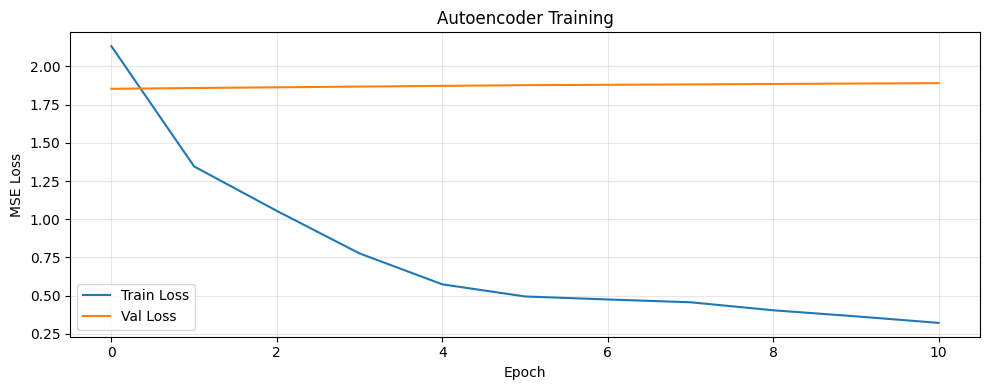

In [62]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "autoencoder_training.png", dpi=150)
plt.show()

---
## 4. Extract Latent Representations

Use the trained encoder to extract compact representations for each video.

In [63]:
# Extract latent representations
print("Extracting latent representations...")
latent_representations = encoder.predict(X_scaled, verbose=0)

print(f"Latent shape: {latent_representations.shape}")
print(f"Each video is now represented by a {CONFIG['encoding_dim']}-dimensional vector")

Extracting latent representations...
Latent shape: (11, 32)
Each video is now represented by a 32-dimensional vector


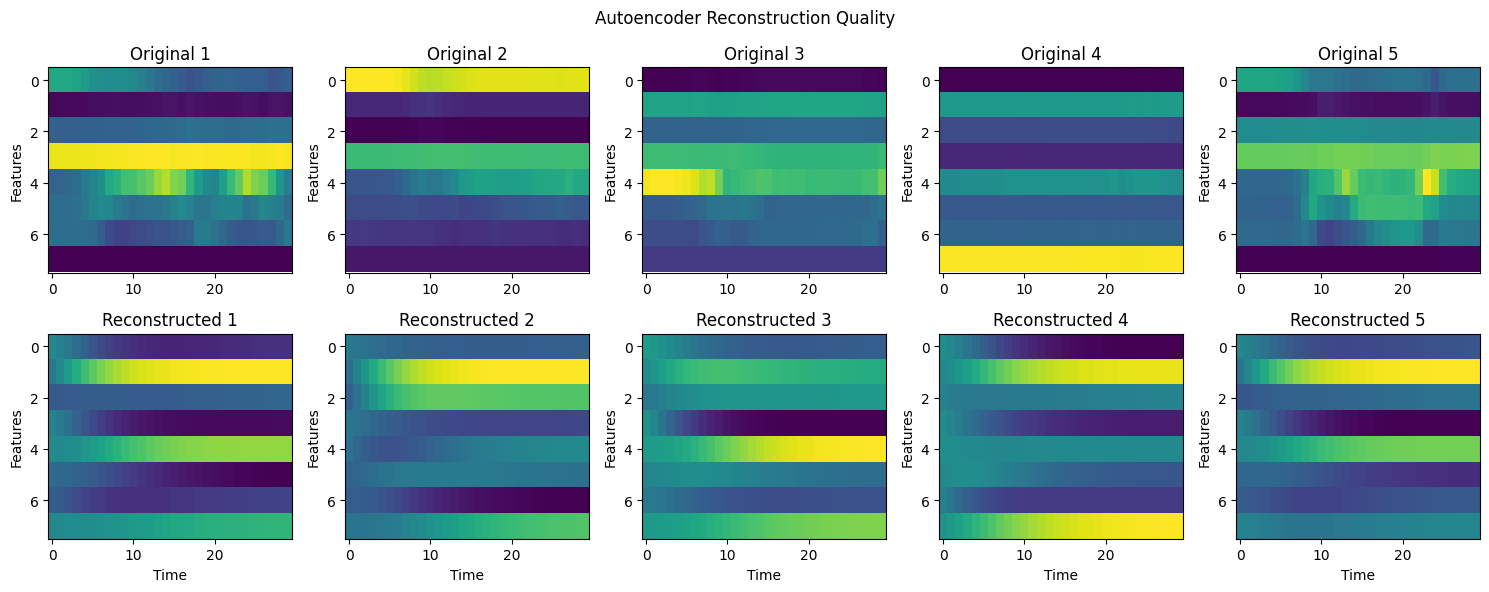

In [64]:
# Visualize reconstruction quality
reconstructed = autoencoder.predict(X_scaled[:5], verbose=0)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    # Original
    axes[0, i].imshow(X_scaled[i].T, aspect='auto', cmap='viridis')
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].set_ylabel("Features")
    
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].T, aspect='auto', cmap='viridis')
    axes[1, i].set_title(f"Reconstructed {i+1}")
    axes[1, i].set_xlabel("Time")
    axes[1, i].set_ylabel("Features")

plt.suptitle("Autoencoder Reconstruction Quality")
plt.tight_layout()
plt.show()

---
## 5. Clustering

Cluster the latent representations to discover natural groupings in the gesture data.

In [65]:
# Determine optimal number of clusters
n_clusters = min(CONFIG["n_clusters"], len(np.unique(y_labels)), 30)
print(f"Using {n_clusters} clusters")

# Try multiple clustering algorithms
clustering_results = {}

# K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(latent_representations)
clustering_results['KMeans'] = kmeans_labels

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(latent_representations)
clustering_results['Agglomerative'] = agglo_labels

print("Clustering complete!")

Using 6 clusters
Clustering complete!


In [66]:
# Evaluate clustering quality
print("\nClustering Evaluation:")
print("=" * 60)

for name, labels in clustering_results.items():
    # Silhouette score (internal metric)
    silhouette = silhouette_score(latent_representations, labels)
    
    # If we have ground truth labels, compute external metrics
    if len(np.unique(y_labels)) > 1:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        y_encoded = le.fit_transform(y_labels)
        
        ari = adjusted_rand_score(y_encoded, labels)
        nmi = normalized_mutual_info_score(y_encoded, labels)
        print(f"{name}:")
        print(f"  Silhouette Score: {silhouette:.4f}")
        print(f"  Adjusted Rand Index: {ari:.4f}")
        print(f"  Normalized Mutual Info: {nmi:.4f}")
    else:
        print(f"{name}: Silhouette Score = {silhouette:.4f}")
    print()


Clustering Evaluation:
KMeans:
  Silhouette Score: 0.4970
  Adjusted Rand Index: 0.1515
  Normalized Mutual Info: 0.7051

Agglomerative:
  Silhouette Score: 0.4970
  Adjusted Rand Index: 0.1515
  Normalized Mutual Info: 0.7051



---
## 6. Visualization

Visualize clusters using dimensionality reduction (PCA/UMAP).

In [67]:
# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
latent_2d_pca = pca.fit_transform(latent_representations)

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=42)
    latent_2d_umap = reducer.fit_transform(latent_representations)
else:
    latent_2d_umap = None

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

PCA explained variance: 79.07%


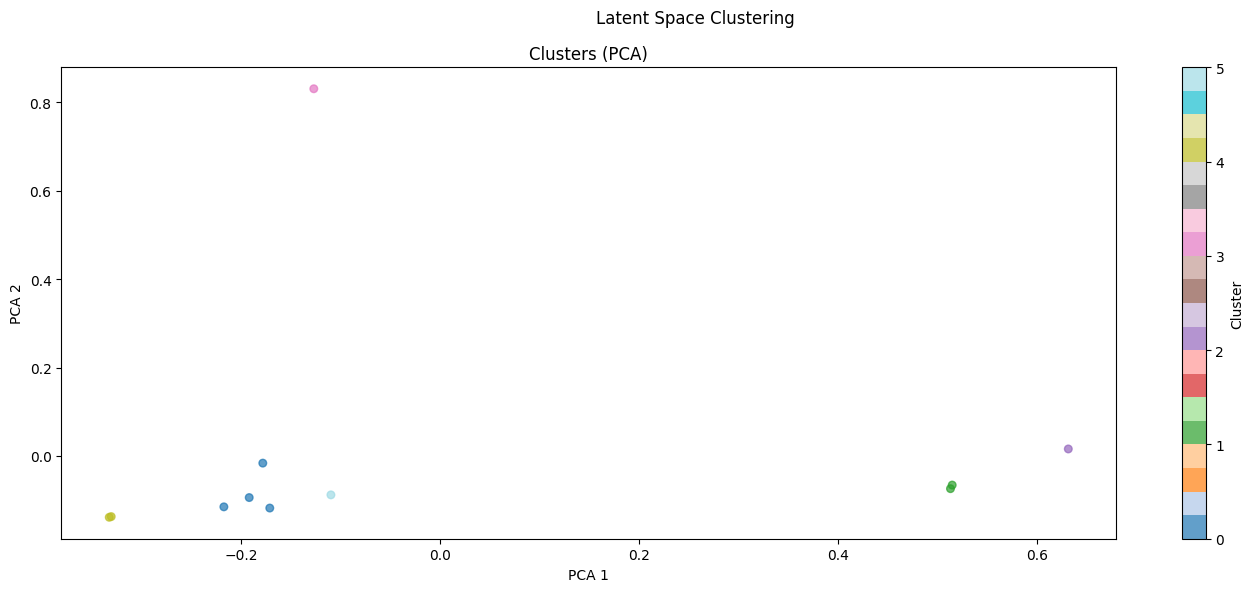

In [68]:
# Plot clusters
fig, axes = plt.subplots(1, 2 if UMAP_AVAILABLE else 1, figsize=(14, 6))
if not UMAP_AVAILABLE:
    axes = [axes]

# Use KMeans labels for visualization
cluster_labels = clustering_results['KMeans']

# PCA plot
scatter1 = axes[0].scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], 
                           c=cluster_labels, cmap='tab20', alpha=0.7, s=30)
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].set_title('Clusters (PCA)')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# UMAP plot
if UMAP_AVAILABLE and latent_2d_umap is not None:
    scatter2 = axes[1].scatter(latent_2d_umap[:, 0], latent_2d_umap[:, 1], 
                               c=cluster_labels, cmap='tab20', alpha=0.7, s=30)
    axes[1].set_xlabel('UMAP 1')
    axes[1].set_ylabel('UMAP 2')
    axes[1].set_title('Clusters (UMAP)')
    plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Latent Space Clustering')
plt.tight_layout()
plt.savefig(MODELS_DIR / "cluster_visualization.png", dpi=150)
plt.show()

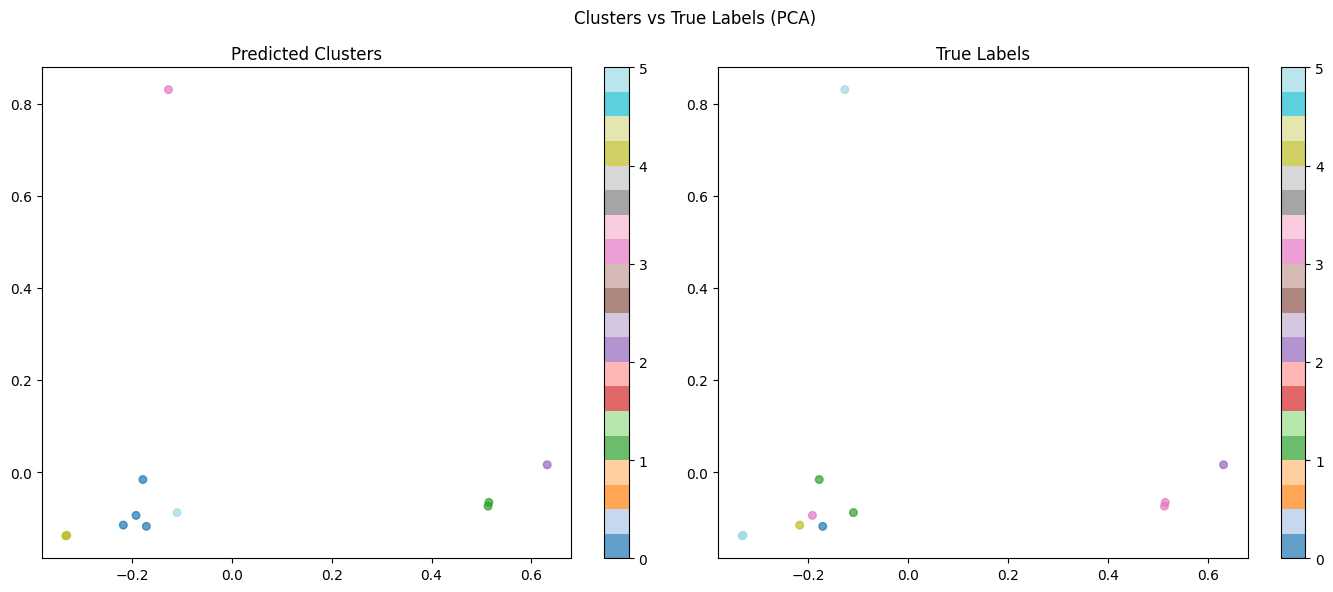

In [69]:
# Color by true labels (if available)
if len(np.unique(y_labels)) > 1:
    le = LabelEncoder()
    y_numeric = le.fit_transform(y_labels)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Predicted clusters
    scatter1 = axes[0].scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], 
                               c=cluster_labels, cmap='tab20', alpha=0.7, s=30)
    axes[0].set_title('Predicted Clusters')
    plt.colorbar(scatter1, ax=axes[0])
    
    # True labels
    scatter2 = axes[1].scatter(latent_2d_pca[:, 0], latent_2d_pca[:, 1], 
                               c=y_numeric, cmap='tab20', alpha=0.7, s=30)
    axes[1].set_title('True Labels')
    plt.colorbar(scatter2, ax=axes[1])
    
    plt.suptitle('Clusters vs True Labels (PCA)')
    plt.tight_layout()
    plt.show()

---
## 7. Map Clusters to Signs

Analyze which signs appear in each cluster and attempt to map clusters to sign classes.

In [70]:
def analyze_cluster_composition(cluster_labels, true_labels):
    """
    Analyze which true labels appear in each cluster.
    """
    cluster_composition = defaultdict(lambda: defaultdict(int))
    
    for cluster, label in zip(cluster_labels, true_labels):
        cluster_composition[cluster][label] += 1
    
    return dict(cluster_composition)

def compute_cluster_purity(cluster_labels, true_labels):
    """
    Compute cluster purity - the proportion of the dominant class in each cluster.
    """
    cluster_composition = analyze_cluster_composition(cluster_labels, true_labels)
    
    total_correct = 0
    for cluster, labels in cluster_composition.items():
        total_correct += max(labels.values())
    
    purity = total_correct / len(cluster_labels)
    return purity

# Analyze clusters
cluster_labels = clustering_results['KMeans']
composition = analyze_cluster_composition(cluster_labels, y_labels)
purity = compute_cluster_purity(cluster_labels, y_labels)

print(f"Overall Cluster Purity: {purity:.4f} ({purity*100:.2f}%)")
print("\n" + "="*60)

Overall Cluster Purity: 0.7273 (72.73%)



In [71]:
# Show cluster composition
print("\nCluster Composition:")
print("="*60)

cluster_mapping = {}  # Map cluster -> dominant sign

for cluster in sorted(composition.keys()):
    labels = composition[cluster]
    total = sum(labels.values())
    dominant_label = max(labels, key=labels.get)
    dominant_count = labels[dominant_label]
    dominant_pct = dominant_count / total * 100
    
    cluster_mapping[cluster] = dominant_label
    
    print(f"\nCluster {cluster} ({total} samples):")
    print(f"  Dominant: {dominant_label} ({dominant_pct:.1f}%)")
    
    # Show top 3 labels
    sorted_labels = sorted(labels.items(), key=lambda x: -x[1])[:3]
    for label, count in sorted_labels:
        pct = count / total * 100
        print(f"    - {label}: {count} ({pct:.1f}%)")


Cluster Composition:

Cluster 0 (4 samples):
  Dominant: 0 (25.0%)
    - 0: 1 (25.0%)
    - 1: 1 (25.0%)
    - 5: 1 (25.0%)

Cluster 1 (2 samples):
  Dominant: 5 (100.0%)
    - 5: 2 (100.0%)

Cluster 2 (1 samples):
  Dominant: 2 (100.0%)
    - 2: 1 (100.0%)

Cluster 3 (1 samples):
  Dominant: 9 (100.0%)
    - 9: 1 (100.0%)

Cluster 4 (2 samples):
  Dominant: 9 (100.0%)
    - 9: 2 (100.0%)

Cluster 5 (1 samples):
  Dominant: 1 (100.0%)
    - 1: 1 (100.0%)


---
## 8. Results Summary

Summary table showing cluster assignments for each sign.

In [72]:
# Create summary DataFrame
def create_summary_table(cluster_labels, true_labels):
    """Create a summary table of sign distribution across clusters."""
    
    # Get unique signs and clusters
    unique_signs = sorted(set(true_labels))
    unique_clusters = sorted(set(cluster_labels))
    
    # Build table
    rows = []
    for sign in unique_signs:
        sign_mask = np.array(true_labels) == sign
        sign_clusters = np.array(cluster_labels)[sign_mask]
        
        cluster_counts = defaultdict(int)
        for c in sign_clusters:
            cluster_counts[c] += 1
        
        total = len(sign_clusters)
        main_cluster = max(cluster_counts, key=cluster_counts.get) if cluster_counts else -1
        main_count = cluster_counts[main_cluster]
        concentration = main_count / total if total > 0 else 0
        
        rows.append({
            'Sign': sign,
            'Total Samples': total,
            'Main Cluster': main_cluster,
            'In Main Cluster': main_count,
            'Concentration': concentration,
            'N Clusters': len(cluster_counts)
        })
    
    return pd.DataFrame(rows)

summary_df = create_summary_table(cluster_labels, y_labels)
summary_df = summary_df.sort_values('Concentration', ascending=False)

print("\nSign Distribution Summary:")
print("=" * 80)
print(summary_df.to_string(index=False))


Sign Distribution Summary:
 Sign  Total Samples  Main Cluster  In Main Cluster  Concentration  N Clusters
    0              1             0                1       1.000000           1
    2              1             2                1       1.000000           1
    7              1             0                1       1.000000           1
    5              3             1                2       0.666667           2
    9              3             4                2       0.666667           2
    1              2             5                1       0.500000           2


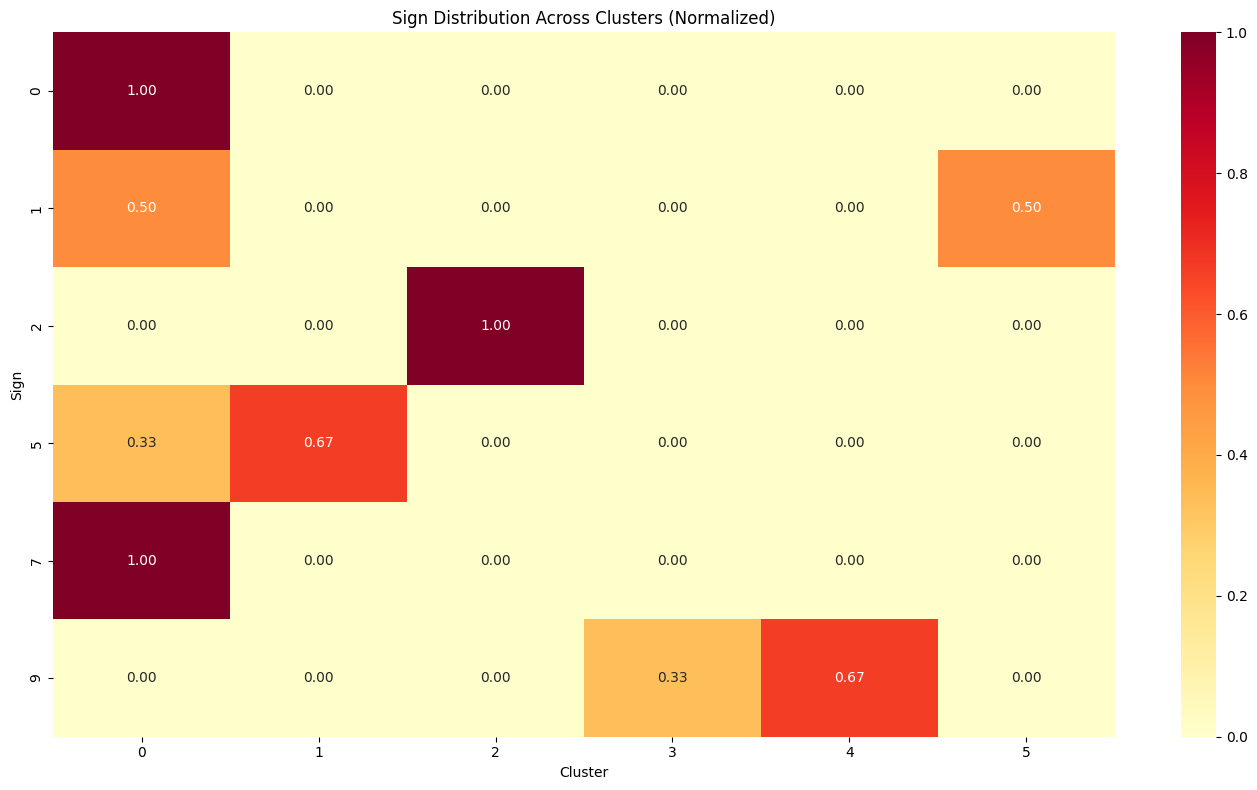

In [73]:
# Visualize sign-cluster relationship as heatmap
def create_sign_cluster_matrix(cluster_labels, true_labels):
    """Create matrix of sign vs cluster counts."""
    unique_signs = sorted(set(true_labels))
    unique_clusters = sorted(set(cluster_labels))
    
    matrix = np.zeros((len(unique_signs), len(unique_clusters)))
    sign_to_idx = {s: i for i, s in enumerate(unique_signs)}
    cluster_to_idx = {c: i for i, c in enumerate(unique_clusters)}
    
    for sign, cluster in zip(true_labels, cluster_labels):
        matrix[sign_to_idx[sign], cluster_to_idx[cluster]] += 1
    
    # Normalize by row (sign)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_normalized = matrix / (row_sums + 1e-10)
    
    return matrix_normalized, unique_signs, unique_clusters

matrix, signs, clusters = create_sign_cluster_matrix(cluster_labels, y_labels)

# Plot heatmap (limit to first 20 signs for readability)
max_signs = min(20, len(signs))
plt.figure(figsize=(14, max(8, max_signs * 0.4)))
sns.heatmap(matrix[:max_signs], 
            xticklabels=clusters, 
            yticklabels=signs[:max_signs],
            cmap='YlOrRd', 
            annot=True if len(clusters) <= 15 else False,
            fmt='.2f')
plt.xlabel('Cluster')
plt.ylabel('Sign')
plt.title('Sign Distribution Across Clusters (Normalized)')
plt.tight_layout()
plt.savefig(MODELS_DIR / "sign_cluster_matrix.png", dpi=150)
plt.show()

---
## 9. Save Models and Results

In [74]:
import joblib

# Save autoencoder
autoencoder.save(str(MODELS_DIR / "lstm_autoencoder.keras"))
encoder.save(str(MODELS_DIR / "lstm_encoder.keras"))

# Save clustering model
joblib.dump(kmeans, str(MODELS_DIR / "kmeans_clusterer.pkl"))

# Save scaler
joblib.dump(scaler, str(MODELS_DIR / "feature_scaler_unsupervised.pkl"))

# Save latent representations
np.save(str(MODELS_DIR / "latent_representations.npy"), latent_representations)

# Save cluster assignments
np.save(str(MODELS_DIR / "cluster_assignments.npy"), cluster_labels)

# Save summary
summary_df.to_csv(str(MODELS_DIR / "clustering_summary.csv"), index=False)

# Save cluster mapping
with open(str(MODELS_DIR / "cluster_mapping.json"), 'w') as f:
    json.dump({int(k): int(v) for k, v in cluster_mapping.items()}, f, indent=2)

print("Saved models and results:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name}: {f.stat().st_size/1024:.1f} KB")

Saved models and results:
  autoencoder_training.png: 45.0 KB
  class_labels.npy: 0.4 KB
  cluster_assignments.npy: 0.2 KB
  cluster_mapping.json: 0.1 KB
  cluster_visualization.png: 38.5 KB
  clustering_summary.csv: 0.2 KB
  confusion_matrix.png: 29.2 KB
  feature_scaler.pkl: 0.8 KB
  feature_scaler_unsupervised.pkl: 0.8 KB
  gesture_model.h5: 1521.2 KB
  gesture_model.keras: 1515.0 KB
  hand_alphabet_model.pkl: 18636.0 KB
  kmeans_clusterer.pkl: 1.5 KB
  label_encoder.pkl: 0.4 KB
  latent_representations.npy: 1.5 KB
  lstm_autoencoder.keras: 866.9 KB
  lstm_best.keras: 1515.0 KB
  lstm_encoder.keras: 164.1 KB
  model_config.json: 0.3 KB
  README.md: 2.5 KB
  shared_backend_state.json: 0.6 KB
  sign_cluster_matrix.png: 53.7 KB
  training_history.png: 53.4 KB
  wlasl_labels.npy: 0.4 KB


---
## 10. Discussion

### Strengths of Unsupervised Approach
1. **No labels required** - Works with unlabeled video data
2. **Discovers patterns** - Finds natural groupings in gesture data
3. **Identifies confusable signs** - Signs that cluster together may be visually similar
4. **Scalable** - Can process large amounts of unlabeled data

### Limitations
1. **No guaranteed alignment** - Clusters may not correspond to semantic sign classes
2. **Dependent on features** - Quality depends on feature extraction (MediaPipe)
3. **Number of clusters** - Must be specified or estimated
4. **Temporal variations** - Different speeds/styles of same sign may split clusters

### Interpretation
- **High purity clusters**: Signs with distinct visual patterns
- **Low purity clusters**: Signs that share similar hand movements
- **Scattered signs**: Signs performed with high variation or ambiguous patterns

### Next Steps
1. Use cluster assignments as pseudo-labels for semi-supervised learning
2. Investigate low-purity clusters to understand sign similarities
3. Try other unsupervised methods (VAE, contrastive learning)
4. Use temporal augmentation for more robust representations

In [75]:
# Final summary
print("\n" + "="*60)
print("UNSUPERVISED LEARNING SUMMARY")
print("="*60)
print(f"\nData:")
print(f"  Samples: {n_samples}")
print(f"  Sequence length: {timesteps}")
print(f"  Features per frame: {n_features}")
print(f"  Unique labels: {len(np.unique(y_labels))}")

print(f"\nModel:")
print(f"  Autoencoder latent dim: {CONFIG['encoding_dim']}")
print(f"  Number of clusters: {n_clusters}")

print(f"\nResults:")
print(f"  Cluster purity: {purity:.4f} ({purity*100:.2f}%)")
print(f"  Silhouette score: {silhouette_score(latent_representations, cluster_labels):.4f}")

if len(np.unique(y_labels)) > 1:
    le = LabelEncoder()
    y_enc = le.fit_transform(y_labels)
    print(f"  Adjusted Rand Index: {adjusted_rand_score(y_enc, cluster_labels):.4f}")
    print(f"  Normalized Mutual Info: {normalized_mutual_info_score(y_enc, cluster_labels):.4f}")

print("\n" + "="*60)


UNSUPERVISED LEARNING SUMMARY

Data:
  Samples: 11
  Sequence length: 30
  Features per frame: 8
  Unique labels: 6

Model:
  Autoencoder latent dim: 32
  Number of clusters: 6

Results:
  Cluster purity: 0.7273 (72.73%)
  Silhouette score: 0.4970
  Adjusted Rand Index: 0.1515
  Normalized Mutual Info: 0.7051

